# MVP — Machine Learning & Analytics
## Previsão de Tendência de Ações de Tecnologia com Séries Temporais
## Link do Notebook no Colab: https://colab.research.google.com/drive/1nGs8xtMRwaZtZ6-GsOhrXB-bevToPE_P?usp=sharing

**Nome:** Emanuel Lacé Aranha

**Matrícula:** 176.968.477-83

**Data:** 10/06/2026

**Dataset:** Dados históricos de ações via `yfinance` (AAPL, GOOG, MSFT, AMZN)

**Tipo de problema:** Previsão de Séries Temporais (Regressão)

---

## Checklist do MVP

| Item | Status |
|---|---|
| Problema definido com contexto, objetivo e tipo de tarefa |  Feito |
| Dataset descrito, com fonte, atributos e restrições |  Feito |
| Dataset carregado por URL pública ou fonte diretamente acessível |  Feito |
| Análise exploratória objetiva, conectada à modelagem |  Feito |
| Divisão adequada em treino/teste respeitando a ordem temporal |  Feito |
| Prevenção de vazamento de dados |  Feito |
| Tratamentos de dados justificados |  Feito |
| Pipeline ou sequência reprodutível de pré-processamento |  Feito |
| Modelo baseline definido |  Feito |
| Pelo menos dois modelos/abordagens comparados |  Feito |
| Ajuste de hiperparâmetros em pelo menos um modelo |  Feito |
| Avaliação com métricas coerentes com o problema |  Feito |
| Discussão de overfitting/underfitting, limitações e melhorias |  Feito |
| Código limpo, organizado e executável do início ao fim |  Feito |
| Conclusão conectada ao objetivo inicial |  Feito |


---
# 1. Definição do Problema

## 1.1 Descrição do Problema

O mercado de ações é um ambiente dinâmico e um dos pilares de estudo do mercado financeiro. No setor de previdência privada, foco da minha atuação profissional, investidores, gestores de fundos e analistas dependem de ferramentas precisas para guiar decisões estratégicas de alocação, compra e venda de ativos. Essas ferramentas, sao resultados de, no geral, estudos de mercado e especulações, sendo também bem imprecisas no curto e longo prazo, a depender de fatores externos inesperados. Assim, foi pensado no desenvolvimento desse trabalho, uma ferramenta adicional tentando entender de que forma podemos auxiliar a tomada de decisão de traders e melhorar o desempenho no mercado financeiro.

Este trabalho foca na previsão do preço de fechamento ajustado de quatro gigantes de tecnologia listadas na bolsa:

- **AAPL** — Apple
- **GOOG** — Google
- **MSFT** — Microsoft
- **AMZN** — Amazon

**Por que Machine Learning?**

Séries temporais financeiras são marcadas por padrões complexos, ruídos e relações não lineares que mudam ao longo do tempo. Modelos estatísticos tradicionais muitas vezes falham em capturar essa dinâmica, especialmente quando influenciada por fatores externos, algo que é crucial para o mercado financeiro. Algoritmos de Machine Learning, por outro lado, destacam-se pela capacidade de cruzar indicadores técnicos (como médias móveis, volatilidade e volume) para projetar preços futuros, tornando esse desafio um cenário ideal para o aprendizado supervisionado.

## 1.2 Objetivo do MVP

> O objetivo deste MVP é construir e avaliar modelos de Machine Learning para prever o preço de fechamento ajustado do dia seguinte de ações de tecnologia (AAPL - Apple, GOOG - Google, MSFT - Microsoft, AMZN - Amazon), comparando um modelo baseline com abordagens mais sofisticadas, e discutindo suas limitações no contexto financeiro.

## 1.3 Tipo de Problema

- **Tipo escolhido:** Previsão de Séries Temporais — Regressão supervisionada com janela temporal.
- **Justificativa:** A variavel-alvo é continua e depende do histórico e do cenário macroeconomico, dessa forma, a ordem cronológica dos dados é uma premissa obrigatória. Assim, a divisão de treino e teste deve respeitar a linha do tempo, eliminando os embaralhamentos comuns

## 1.4 Premissas, Hipóteses e Critérios de Sucesso

**Hipóteses iniciais:**
1. O preço de fechamento do próximo dia é correlacionado com o comportamento de preço e volume dos dias anteriores.
2. Indicadores técnicos de momento e volatilidade capturam tendências de curto prazo e melhoram a capacidade de previsão.
3. Modelos que capturam relações não-lineares, como Random Forest e Gradient Boosting, apresentam desempenho superior a modelos lineares simples.

**Critérios de sucesso:**
- Métrica principal: **Root Mean Squared Error (RMSE)**, por penalizar erros de maior magnitude, o que é crítico para a precificação de ativos.
- Métricas complementares: **MAE** e **R²**.
- Resultado mínimo esperado: Superar o baseline da previsão ingênua (último preço observado).
- Restrição prática: O treinamento e a validação do modelo devem ser feitos sem o uso de dados futuros, eliminando qualquer risco de data leakage.


---
# 2. Ambiente e Configuração

Antes de começar, vamos organizar o ambiente: instalar as bibliotecas necessárias, definir a seed para reprodutibilidade e criar as funções que vão ser usadas ao longo do notebook.

---
## 2.0 Configuração de Ambiente

### 2.0.1. Instalação de bibs adicionais

In [ ]:

!pip install -q yfinance pandas-datareader


### 2.0.2. Importação de bibs

In [ ]:
import os
import sys
import time
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import yfinance as yf
from datetime import datetime, timedelta
from scipy.stats import randint, uniform



### 2.0.3 Configuração de ambiente

In [ ]:
warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.style.use("fivethirtyeight")
%matplotlib inline

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

print(f"Python : {sys.version.split()[0]}")
print(f"Pandas : {pd.__version__}")
print(f"NumPy  : {np.__version__}")
print(f"Seed   : {SEED}")

Python : 3.12.13
Pandas : 2.2.2
NumPy  : 2.0.2
Seed   : 42


## 2.1 Funções Auxiliares

Centralizar funções de avaliação e visualização evita repetição de código e facilita comparações entre modelos.


In [ ]:
def evaluate_regression(y_true, y_pred, model_name="modelo"):
    """
    Calculo de MAE, RMSE, R² e MAPE
    """
    mse = mean_squared_error(y_true, y_pred)
    y_true_arr = np.array(y_true)
    y_pred_arr = np.array(y_pred)
    mape = np.mean(np.abs((y_true_arr - y_pred_arr) / y_true_arr)) * 100

    return {
        "Modelo": model_name,
        "MAE":    round(mean_absolute_error(y_true, y_pred), 4),
        "RMSE":   round(np.sqrt(mse), 4),
        "R2":     round(r2_score(y_true, y_pred), 4),
        "MAPE(%)": round(mape, 4),
    }


def plot_predictions(y_true, y_pred, title="Previsão vs. Real", ticker=""):
    """
    Plota a série real vs. série prevista no conjunto de teste.
    """
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(y_true.values,  label="Real",    linewidth=1.5)
    ax.plot(y_pred,         label="Previsto", linewidth=1.5, linestyle="--")
    ax.set_title(f"{title} — {ticker}", fontsize=13)
    ax.set_xlabel("Amostras (conjunto de teste)")
    ax.set_ylabel("Preço de Fechamento Ajustado (USD)")
    ax.legend()
    plt.tight_layout()
    plt.show()


def plot_residuals(y_true, y_pred, title="Análise de Resíduos", ticker=""):
    """
    Plota os resíduos (erro = real − previsto) ao longo do conjunto de teste.
    """
    residuals = np.array(y_true) - np.array(y_pred)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(residuals, color="steelblue", linewidth=1)
    axes[0].axhline(0, color="red", linestyle="--")
    axes[0].set_title(f"Resíduos ao longo do tempo — {ticker}")
    axes[0].set_xlabel("Amostras")
    axes[0].set_ylabel("Resíduo")

    axes[1].hist(residuals, bins=30, color="steelblue", edgecolor="white")
    axes[1].set_title("Distribuição dos Resíduos")
    axes[1].set_xlabel("Resíduo")
    axes[1].set_ylabel("Frequência")

    plt.suptitle(title, fontsize=12)
    plt.tight_layout()
    plt.show()

Funções auxiliares carregadas com sucesso.


---
# 3. Dados

## 3.1 De onde vêm os dados?

Vou usar dados históricos de preços de quatro ações de tecnologia, baixados diretamente pelo `yfinance` — uma biblioteca Python que acessa o Yahoo Finance sem precisar de cadastro ou chave de API.

O período cobre os últimos 5 anos (até 10/06/2026 - para garantir 100% de reprodutibilidade), com dados diários de cada pregão.

**Por que esse dataset?**
- É público, gratuito e qualquer pessoa consegue rodar o notebook sem configuração adicional.
- Ações de tecnologia têm tendências claras e volume alto — um bom campo de teste para ML aplicado a finanças.
- Trabalho no setor de previdência privada, então entender o comportamento dessas ações tem aplicação direta no meu dia a dia.

**Limitações que já sei de antemão:**
- O modelo só vai ver dados históricos — notícias, balanços e decisões de política monetária não entram.
- Padrões aprendidos no passado podem não se repetir em crises ou mudanças de cenário econômico.
- Os preços já vêm ajustados por splits e dividendos, o que pode criar pequenas descontinuidades históricas.

In [ ]:
#Informações que vão ser extraídas e variável target
TICKERS       = ["AAPL", "GOOG", "MSFT", "AMZN"]
COMPANY_NAMES = {"AAPL": "Apple", "GOOG": "Google", "MSFT": "Microsoft", "AMZN": "Amazon"}
YEARS_BACK    = 5
TARGET_COL    = "Close"

end_date = datetime(2026, 6, 10)
start_date = datetime(end_date.year - YEARS_BACK, end_date.month, end_date.day)

print(f"Período: {start_date.strftime('%Y-%m-%d')} → {end_date.strftime('%Y-%m-%d')}")

# Dicionário que armazenará o DataFrame de cada ação
stock_data = {}

for ticker in TICKERS:
    df_tmp = yf.download(ticker, start=start_date, end=end_date, auto_adjust=True, progress=False)

    # yfinance pode retornar MultiIndex — achatar para colunas simples
    if isinstance(df_tmp.columns, pd.MultiIndex):
        df_tmp.columns = [col[0] for col in df_tmp.columns]

    df_tmp.index = pd.to_datetime(df_tmp.index)
    df_tmp["Ticker"] = ticker
    df_tmp["Company"] = COMPANY_NAMES[ticker]
    stock_data[ticker] = df_tmp
    print(f"  {ticker}: {len(df_tmp)} registros carregados.")

# DataFrame consolidado
df_all = pd.concat(stock_data.values(), axis=0).sort_index()
print(f"\nDataset consolidado: {df_all.shape[0]} linhas × {df_all.shape[1]} colunas")
df_all.tail(5)


Período: 2021-06-10 → 2026-06-10
  AAPL: 1255 registros carregados.
  GOOG: 1255 registros carregados.
  MSFT: 1255 registros carregados.
  AMZN: 1255 registros carregados.

Dataset consolidado: 5020 linhas × 7 colunas


,Close,High,Low,Open,Volume,Ticker,Company
Date,,,,,,,
2026-06-08,301.540009,317.399994,301.170013,308.739990,77949100,AAPL,Apple
2026-06-09,362.290009,369.691986,354.720001,364.885010,19873600,GOOG,Google
2026-06-09,290.549988,300.750000,287.779999,300.279999,70108800,AAPL,Apple
2026-06-09,403.410004,411.980011,398.480011,409.029999,35317300,MSFT,Microsoft
2026-06-09,244.190002,250.429993,240.399994,247.729996,44425400,AMZN,Amazon


## 3.2 Visão Geral do Dataset

Antes de modelar, é importante apresentar uma visão geral do dataset

### 3.2.1 Estrutura geral dos dados

In [ ]:
print("Formato do dataset consolidado (linhas, colunas):", df_all.shape)
print("\nColunas e tipos:")
display(df_all.dtypes.to_frame("Tipo"))

print("\nValores ausentes por coluna:")
display(df_all.isna().sum().to_frame("Ausentes"))

print("\nDuplicatas:", df_all.duplicated().sum())


Formato do dataset consolidado (linhas, colunas): (5020, 7)

Colunas e tipos:


,Tipo
Close,float64
High,float64
Low,float64
Open,float64
Volume,int64
Ticker,object
Company,object



Valores ausentes por coluna:


,Ausentes
Close,0
High,0
Low,0
Open,0
Volume,0
Ticker,0
Company,0



Duplicatas: 0


### 3.2.3 Dicionário de dados

| Coluna | Tipo | Descrição | Será usada no modelo? | Observações |
|---|---|---|---|---|
| Date | Data | Índice temporal do pregão | Sim | Usada para ordenar a série e garantir a divisão temporal correta |
| Close | Numérica | Preço de fechamento ajustado | Sim | Base para lags, médias móveis, desvio padrão, retorno diário e variável-alvo |
| High | Numérica | Preço máximo do pregão | Sim | Usada para calcular `high_low_range = High − Low` |
| Low | Numérica | Preço mínimo do pregão | Sim | Usada para calcular `high_low_range = High − Low` |
| Open | Numérica | Preço de abertura do pregão | Não | Presente no DataFrame de entrada mas descartada na engenharia de features — o preço de fechamento do dia anterior (`close_lag_1`) captura a mesma informação de nível de preço com mais relevância preditiva |
| Volume | Numérica | Quantidade de ações negociadas | Sim | Transformada em `volume_lag_1` — volume do dia anterior como proxy de liquidez |
| Ticker | Texto | Código da ação na bolsa | Sim | Variável de identificação, sem poder preditivo. Usada apenas para organização do dataset consolidado |
| Company | Texto | Nome da empresa | Sim | Variável de identificação, sem poder preditivo. Usada apenas para legibilidade nas visualizações |
| Target | Numérica | Preço de fechamento do dia seguinte | Alvo | Criada via `Close.shift(-1)` — representa o valor que o modelo deve prever |

### 3.2.4 Estatísticas gerais por Ticker, sobre a variável target

In [ ]:
display(
    df_all.groupby("Ticker")[TARGET_COL]
    .describe()
    .round(2)
)


,count,mean,std,min,25%,50%,75%,max
Ticker,,,,,,,,
AAPL,1255.0,191.85,44.07,122.93,154.41,180.82,225.57,315.20
AMZN,1255.0,169.86,45.64,81.82,132.03,172.19,207.24,274.99
GOOG,1255.0,166.23,68.43,82.76,124.28,143.08,177.91,398.80
MSFT,1255.0,357.21,84.41,207.73,280.83,363.54,418.26,538.66


---
# 4. Análise Exploratória

Antes de modelar qualquer coisa, preciso entender o que os dados mostram. Essa etapa ajuda a identificar padrões, detectar problemas e guiar as decisões de engenharia de features que vêm na sequência.

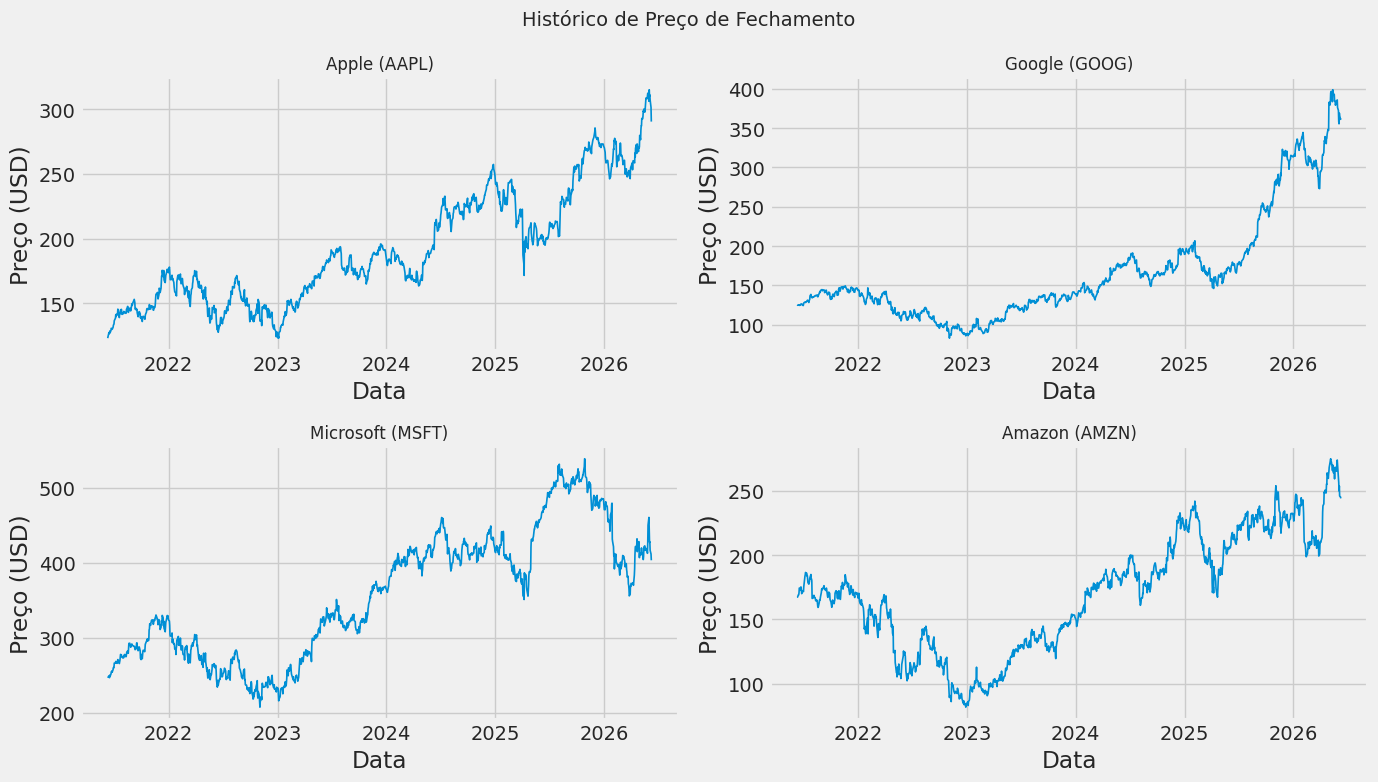

In [ ]:
# === Histórico de preços de fechamento ===
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()
for i, ticker in enumerate(TICKERS):
    ax = axes[i]
    df_t = stock_data[ticker]
    ax.plot(df_t.index, df_t[TARGET_COL], linewidth=1.2)
    ax.set_title(f"{COMPANY_NAMES[ticker]} ({ticker})", fontsize=12)
    ax.set_xlabel("Data")
    ax.set_ylabel("Preço (USD)")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.suptitle("Histórico de Preço de Fechamento", fontsize=14)
plt.tight_layout()
plt.show()


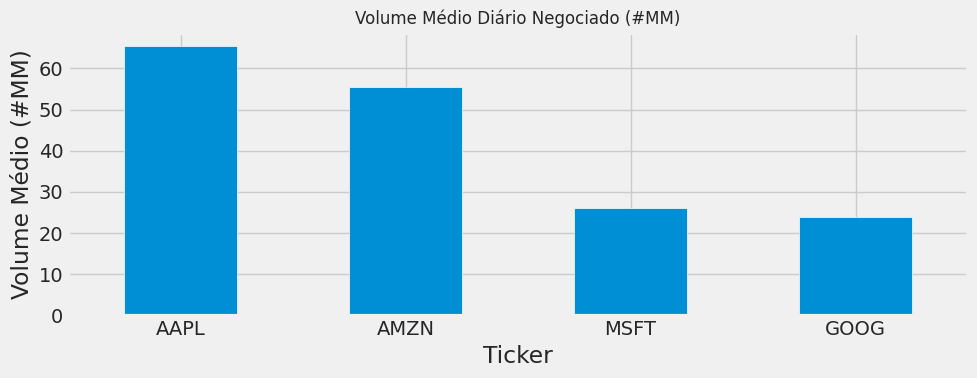

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))

vol_mean = df_all.groupby("Ticker")["Volume"].mean() / 1e6  # em milhões
vol_mean.sort_values(ascending=False).plot(kind="bar", ax=ax, edgecolor="white")
ax.set_title("Volume Médio Diário Negociado (#MM)", fontsize=12)
ax.set_xlabel("Ticker")
ax.set_ylabel("Volume Médio (#MM)")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()


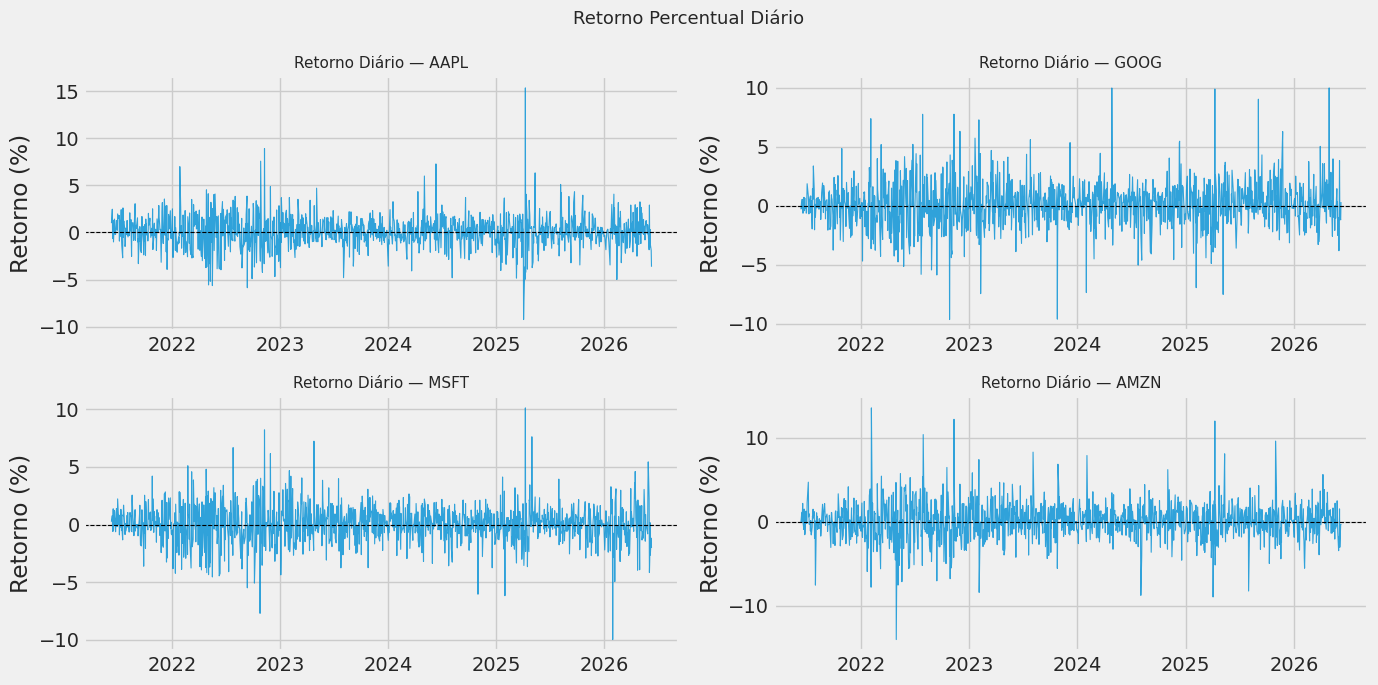

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 7))
axes = axes.flatten()

for i, ticker in enumerate(TICKERS):
    df_t = stock_data[ticker].copy()
    df_t["daily_return"] = df_t[TARGET_COL].pct_change() * 100
    axes[i].plot(df_t.index, df_t["daily_return"], linewidth=0.8, alpha=0.8)
    axes[i].axhline(0, color="black", linewidth=0.8, linestyle="--")
    axes[i].set_title(f"Retorno Diário — {ticker}", fontsize=11)
    axes[i].set_ylabel("Retorno (%)")
    axes[i].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.suptitle("Retorno Percentual Diário", fontsize=13)
plt.tight_layout()
plt.show()


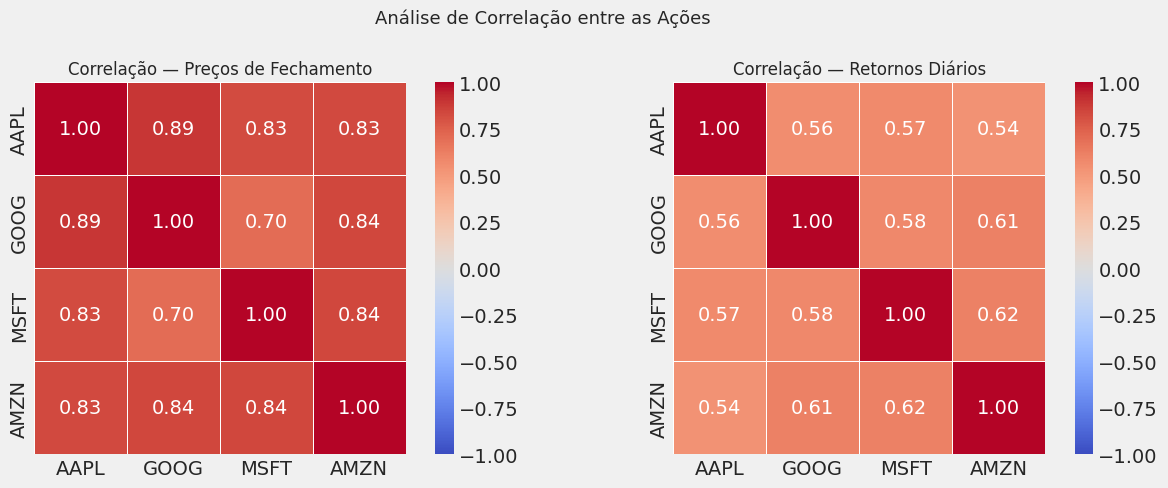

In [ ]:
# === Correlação entre preços de fechamento E retornos diários ===

pivot_close   = pd.DataFrame({t: stock_data[t][TARGET_COL] for t in TICKERS})
pivot_returns = pivot_close.pct_change().dropna()

corr_prices  = pivot_close.corr()
corr_returns = pivot_returns.corr()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, matrix, title in zip(
    axes,
    [corr_prices, corr_returns],
    ["Correlação — Preços de Fechamento", "Correlação — Retornos Diários"]
):
    sns.heatmap(
        matrix, annot=True, fmt=".2f", cmap="coolwarm",
        vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax
    )
    ax.set_title(title, fontsize=12)

plt.suptitle("Análise de Correlação entre as Ações", fontsize=13)
plt.tight_layout()
plt.show()

**Leitura dos mapas de correlação:**

- **Preços de fechamento:** correlações entre 0,69 e 0,89 — todas positivas e
  moderadamente altas. O par GOOG–MSFT apresenta a menor correlação (0,69),
  enquanto AAPL–GOOG é o mais correlacionado (0,89). Ainda assim, essa medida
  pode ser **enganosa**: preços com tendência de alta ao longo de anos tendem a
  se correlacionar mesmo que não se movam juntos no dia a dia.

- **Retornos diários:** correlações entre 0,54 e 0,62 — mais baixas e mais
  honestas sobre a co-movimentação real entre os ativos. AAPL é a ação menos
  correlacionada com as demais (0,54–0,57), sugerindo dinâmica de preço mais
  independente. GOOG, MSFT e AMZN apresentam correlações similares entre si
  (~0,58–0,62), indicando maior sincronismo de movimentos diários.

> Para a modelagem, as correlações de retornos reforçam que features de
> uma ação (ex: retorno da MSFT) poderiam, em teoria, enriquecer o modelo
> de outra. Esse tipo de feature cross-asset não foi incluído neste MVP,
> mas representa uma oportunidade de melhoria futura. Porém, poderia ser uma boa melhoria para um modelo futuro. Apesar de não ser possível ver isso nos dados acima, geralmente em fechamentos, ações de tecnologia tendem a subir juntas. Então, Apple e Microsoft, tendem a subir se uma ou outra sobe, pois ambas são empresas do mesmo ramo de tecnologia (softwares), apesar de que recentemente terem começado a explorar diferentes mercados.

**Principais observações:**

1. Todas as ações apresentam tendência de alta ao longo dos 5 anos, com períodos de queda (notavelmente em 2022).
2. AMZN e MSFT têm maior volatilidade absoluta em dólares, enquanto GOOG apresenta crescimento mais estável no período, padrão esperado devido a quantidade de ações negociadas diariamente.
3. Os retornos diários oscilam predominantemente entre −5% e +5%, com alguns outliers em momentos de crise.
4. A correlação entre os ativos é alta (> 0,82 - EX GOOGL), o que é esperado para ações do mesmo setor. Isso sugere que modelos construídos para uma ação podem ter estrutura similar para as demais.
5. AAPL é a ação de maior volume de negociações, esperado de um dos ativos mais líquidos do mundo.


---
# 5. Preparação dos Dados, Engenharia de Features e decisões de Pré processamento

Modelos de ML não trabalham com séries temporais brutas — precisamos transformar os dados em um formato tabular onde cada linha representa um dia e cada coluna é uma informação disponível naquele momento.

A ideia central é simples: para prever o preço de amanhã, uso informações de hoje e dos dias anteriores.


## 5.1 Estratégia de Features

Para prever o preço de fechamento do **dia seguinte** (`target = Close_{t+1}`), criamos features baseadas em **janelas temporais passadas** — uma abordagem clássica em séries temporais supervisionadas.

**Features criadas:**

| Feature | Descrição | Justificativa |
|---|---|---|
| `close_lag_1` a `close_lag_5` | Preço de fechamento dos últimos N dias | Captura momentum de curto prazo |
| `volume_lag_1` | Volume do dia anterior | Liquidez influencia preços |
| `ma_5`, `ma_10`, `ma_20` | Médias móveis de 5, 10 e 20 dias | Indicadores técnicos amplamente utilizados |
| `std_5`, `std_10` | Desvio padrão dos últimos 5 e 10 dias | Mede volatilidade recente |
| `return_1d` | Retorno percentual diário | Normaliza a série e captura aceleração |
| `high_low_range` | Amplitude entre máxima e mínima do dia | Proxy de volatilidade intraday |

**Cuidados com data leakage:**
- O `target` é sempre o preço do **dia seguinte** (`shift(-1)`).
- Todas as features usam apenas informações do **dia atual e anteriores**.
- A normalização (StandardScaler) é ajustada **apenas no conjunto de treino** e aplicada ao teste.


In [ ]:
def build_features(df_ticker: pd.DataFrame) -> pd.DataFrame:
    """
    Cria features de janela temporal para previsão do preço do próximo dia.
    """
    df = df_ticker[["Open", "High", "Low", "Close", "Volume"]].copy()

    #  Lags de preço de fechamento
    for lag in range(1, 6):
        df[f"close_lag_{lag}"] = df["Close"].shift(lag)

    #  Lag de volume
    df["volume_lag_1"] = df["Volume"].shift(1)

    #  Médias móveis
    for w in [5, 10, 20]:
        df[f"ma_{w}"] = df["Close"].rolling(w).mean()

    #  Desvio padrão (volatilidade)
    for w in [5, 10]:
        df[f"std_{w}"] = df["Close"].rolling(w).std()

    #  Retorno diário percentual
    df["return_1d"] = df["Close"].pct_change()

    #  Amplitude diária (High − Low)
    df["high_low_range"] = df["High"] - df["Low"]

    #  Variável-alvo: preço de fechamento do próximo dia
    df["target"] = df["Close"].shift(-1)

    # Remove linhas com NaN geradas pelos lags e médias móveis - o que não é problematico pois são apenas as primeiras linhas do dataset.
    df.dropna(inplace=True)

    return df


# Colunas que serão usadas como features (excluindo OHLCV originais e target)
FEATURE_COLS = [
    "close_lag_1", "close_lag_2", "close_lag_3", "close_lag_4", "close_lag_5",
    "volume_lag_1",
    "ma_5", "ma_10", "ma_20",
    "std_5", "std_10",
    "return_1d",
    "high_low_range",
]

# Criar features para todos os tickers
features_data = {ticker: build_features(stock_data[ticker]) for ticker in TICKERS}

print("Exemplo de features — AAPL:")
display(features_data["AAPL"][FEATURE_COLS + ["target"]].tail(5))
print(f"\nDimensões após engenharia de features:")
for t, df_t in features_data.items():
    print(f"  {t}: {df_t.shape}")


Exemplo de features — AAPL:


,close_lag_1,close_lag_2,close_lag_3,close_lag_4,close_lag_5,volume_lag_1,ma_5,ma_10,ma_20,std_5,std_10,return_1d,high_low_range,target
Date,,,,,,,,,,,,,,
2026-06-02,306.309998,312.059998,312.510010,310.850006,308.329987,48849900.0,311.386005,308.029001,300.715460,3.252593,4.989756,0.029023,8.760010,310.260010
2026-06-03,315.200012,306.309998,312.059998,312.510010,310.850006,44534700.0,311.268005,309.158002,302.032539,3.287415,3.862131,-0.015673,8.089996,311.230011
2026-06-04,310.260010,315.200012,306.309998,312.059998,312.510010,50836700.0,311.012006,310.056003,303.231772,3.215571,3.032293,0.003126,3.890015,307.339996
2026-06-05,311.230011,310.260010,315.200012,306.309998,312.059998,44869100.0,310.068005,310.291003,304.240001,3.510316,2.664857,-0.012499,8.020020,301.540009
2026-06-08,307.339996,311.230011,310.260010,315.200012,306.309998,65310500.0,309.114008,309.563004,304.664500,5.082884,3.844612,-0.018872,16.229980,290.549988



Dimensões após engenharia de features:
  AAPL: (1235, 19)
  GOOG: (1235, 19)
  MSFT: (1235, 19)
  AMZN: (1235, 19)


## 5.2 Decisões de Pré-processamento

### Imputação de valores ausentes

O dataset não apresentou valores ausentes nas colunas originais do Yahoo Finance
(`Open`, `High`, `Low`, `Close`, `Volume`). Os únicos valores ausentes gerados
foram os introduzidos intencionalmente pelas próprias transformações, dessa forma apenas removemos, pois imputar esses valores seria equivalente
a inventar histórico inexistente.

---

### Por que padronizar com StandardScaler?

O StandardScaler transforma cada feature para ter média zero e desvio padrão um.
Isso foi necessário por duas razões práticas no contexto deste dataset.

A primeira é a diferença de escala entre as features. O preço de fechamento da
AMZN pode estar na casa dos $3.000, enquanto o retorno diário percentual oscila
entre −5% e +5%. Sem padronização, modelos sensíveis a magnitude — como a
Regressão Ridge — teriam seus coeficientes distorcidos pelas variáveis de maior
escala absoluta.

A segunda é a estabilidade do Gradient Boosting e do Random Forest. Embora árvores
de decisão sejam teoricamente invariantes à escala, a padronização dentro do
Pipeline não prejudica esses modelos e garante que o notebook seja consistente
e reutilizável caso outros algoritmos sejam testados futuramente.

O scaler foi encapsulado no Pipeline e ajustado exclusivamente com os dados de
treino, evitando qualquer vazamento de informações do teste.

---

### Quais variáveis foram removidas e por quê?

As colunas `Open`, `High`, `Low` e `Volume` originais foram substituídas por
versões transformadas. O valor bruto de abertura de um pregão, por exemplo,
carrega menos informação preditiva isolado do que quando combinado com o
fechamento anterior (capturado pelos lags) ou com a amplitude do dia
(`high_low_range = High − Low`).

A coluna `Ticker` e `Company` foram mantidas apenas para organização do dataset
consolidado e não entraram como features do modelo — são variáveis de
identificação, não preditoras.

---

### Novas variáveis criadas (Engenharia de Features)

Todas as features foram construídas exclusivamente a partir de informações
disponíveis *antes* do momento da previsão — uma exigência fundamental para
que o modelo seja utilizável em produção.

O ponto crítico é que nenhuma feature usa `shift(0)` sobre o target nem qualquer
valor futuro. A função `rolling()` do pandas é causal por definição: o valor
calculado para o dia `t` usa apenas os dias `t-N` até `t`, nunca `t+1` em diante.
Isso garante que a engenharia de features é segura e não introduz vazamento de
dados de forma velada.

---
## 5.3. Divisão Temporal dos Dados

## Estratégia de Divisão dos Dados

### Por que divisão temporal (holdout temporal) em vez de validação cruzada tradicional?

Em séries temporais, a ordem dos dados é fundamental — o passado causa o futuro,
e nunca o contrário. O `KFold` tradicional embaralha os dados aleatoriamente antes
de criar as partições, o que significa que o modelo poderia ser treinado com dados
de 2024 e testado com dados de 2022. Isso não representa nenhum cenário real e
produz métricas otimistas e enganosas.

Por isso, adotamos **holdout temporal**: os primeiros 80% dos pregões formam o
conjunto de treino, e os 20% mais recentes formam o conjunto de teste. O modelo
aprende com o passado e é avaliado no futuro — exatamente como funcionaria em
produção.

Para a etapa de otimização de hiperparâmetros, foi utilizado o `TimeSeriesSplit`
do scikit-learn, que realiza validação cruzada respeitando a ordem temporal: cada
fold garante que o conjunto de validação é sempre posterior ao conjunto de treino
daquela iteração.

---

### A proporção 80/20 faz sentido para o tamanho do dataset?

Com 5 anos de dados e aproximadamente 1.250 pregões por ação, a divisão 80/20
resulta em cerca de **1.000 amostras para treino** e **250 para teste** — volumes
adequados para os modelos utilizados (Ridge, Random Forest, Gradient Boosting).

Um conjunto de teste com 250 amostras representa aproximadamente 1 ano de pregões,
o que é suficiente para cobrir diferentes condições de mercado (alta, baixa,
lateralização) e produzir métricas de avaliação estatisticamente confiáveis.

Proporções mais agressivas (como 90/10) reduziriam o teste a apenas ~125 amostras,
aumentando a variância das métricas. Proporções mais conservadoras (como 70/30)
diminuiriam o treino e poderiam prejudicar a capacidade dos modelos de aprender
padrões de longo prazo.

---

### Como a divisão evita vazamento de dados?

O vazamento de dados ocorre quando informações do conjunto de teste influenciam,
direta ou indiretamente, o treinamento do modelo. Três decisões de projeto eliminam
esse risco:

**Corte temporal estrito:** o índice de separação é calculado uma única vez e
aplicado de forma sequencial. Nenhum dado posterior ao corte é acessado durante
o treino.

**Target com `shift(-1)`:** a variável-alvo de cada amostra é o preço do dia
*seguinte*, nunca do dia atual. Isso garante que o modelo sempre prevê algo que,
no momento da feature, ainda não aconteceu.

**StandardScaler dentro do Pipeline:** o escalonamento é ajustado exclusivamente
com os dados de treino (`fit` apenas em `X_train`) e aplicado ao teste sem
re-ajuste (`transform` em `X_test`). Se o scaler fosse ajustado no dataset
completo antes da divisão, ele carregaria informações estatísticas do teste
(média e desvio padrão globais) para dentro do treino — uma forma sutil, porém
real, de vazamento.

In [ ]:

TRAIN_RATIO = 0.80

splits = {}

for ticker in TICKERS:
    df_feat = features_data[ticker]

    n = len(df_feat)
    split_idx = int(n * TRAIN_RATIO)

    X = df_feat[FEATURE_COLS]
    y = df_feat["target"]

    X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

    splits[ticker] = {
        "X_train": X_train, "X_test": X_test,
        "y_train": y_train, "y_test": y_test,
    }

    print(f"{ticker}: {len(X_train)} treino | {len(X_test)} teste "
          f"| corte em {X_test.index[0].strftime('%Y-%m-%d')}")

print("\nDivisão temporal concluída. Nenhum dado de teste foi utilizado no treino.")


AAPL: 988 treino | 247 teste | corte em 2025-06-13
GOOG: 988 treino | 247 teste | corte em 2025-06-13
MSFT: 988 treino | 247 teste | corte em 2025-06-13
AMZN: 988 treino | 247 teste | corte em 2025-06-13

Divisão temporal concluída. Nenhum dado de teste foi utilizado no treino.


# 7. Baseline e Modelos Candidatos

## Por que começar com um baseline?

O baseline estabelece o piso mínimo de desempenho: se um modelo complexo não
superar uma solução trivial, ele não aprendeu nada útil. Neste problema, dois
baselines foram definidos para criar referências progressivas.

---

## Baselines

**Baseline 1 — DummyRegressor (Média Histórica):** prediz sempre a média do
treino, ignorando qualquer padrão temporal. É o piso absoluto — qualquer modelo
deve superá-lo.

**Baseline 2 — Naive Lag-1:** usa o preço de ontem como previsão de hoje. É o benchmark principal deste problema — qualquer modelo que não supere essa referência simples não tem valor prático.

---

## Modelos Candidatos

**Ridge Regression:** modelo linear com regularização L2. A regularização é
importante aqui porque as features de lag e médias móveis são altamente
correlacionadas entre si — a Ridge distribui os pesos de forma estável, evitando
os problemas de instabilidade da regressão linear pura.

**Random Forest:** ensemble de árvores com bagging. Captura não-linearidades,
é robusto a outliers e serve como transição entre a simplicidade da Ridge e o
poder do Gradient Boosting.

**Gradient Boosting:** ensemble sequencial onde cada árvore corrige os erros
da anterior. Maior capacidade preditiva entre os candidatos, especialmente
em dados tabulares com features de engenharia — o caso deste MVP.

In [ ]:
# === Definição dos modelos em pipelines ===

def build_models(seed=42):
    """
    Retorna dicionário com pipelines de pré-processamento + modelo.
    """
    return {
        "Ridge": Pipeline([
            ("scaler", StandardScaler()),
            ("model",  Ridge(random_state=seed))
        ]),
        "RandomForest": Pipeline([
            ("scaler", StandardScaler()),
            ("model",  RandomForestRegressor(n_estimators=100, random_state=seed, n_jobs=-1))
        ]),
        "GradientBoosting": Pipeline([
            ("scaler", StandardScaler()),
            ("model",  GradientBoostingRegressor(n_estimators=100, random_state=seed))
        ]),
    }

print("Pipelines definidos:", list(build_models().keys()))


Pipelines definidos: ['Ridge', 'RandomForest', 'GradientBoosting']


## 7.1 Justificativa dos Modelos

**O baseline é coerente?**
Sim. O Naive Lag-1 é o baseline padrão da literatura para séries financeiras
diárias — é simples, sem parâmetros, e difícil de superar justamente porque
preços consecutivos são muito parecidos. Qualquer modelo que não o supere
não tem valor prático.

**Os modelos são adequados ao tipo e tamanho dos dados?**
Com aproximadamente 1.000 amostras de treino e 13 features tabulares, os três modelos são
bem calibrados para este tamanho de dataset. Modelos muito complexos como
redes neurais profundas seriam excessivos aqui — tenderiam ao overfitting
sem ganho expressivo de desempenho.

**Algum modelo exige tratamento específico?**
A Ridge Regression é sensível à escala das features, o que justifica o uso
do StandardScaler no Pipeline. Random Forest e Gradient Boosting são
invariantes à escala por natureza (baseados em árvores), mas o scaler foi
mantido para consistência entre os pipelines.

**Há restrições de custo computacional?**
Random Forest e Gradient Boosting têm custo de treino maior que a Ridge, mas
ainda executam em poucos segundos no Colab com este volume de dados. O
Gradient Boosting é o mais lento dos três por ser sequencial, mas o tempo
permanece aceitável (~2–5s por ação). Nenhum modelo exige GPU.

---
# 8. Treinamento e Avaliação Inicial

Com os dados preparados e os modelos definidos, é hora de treinar tudo e ver o que acontece. Vou comparar os baselines com os três modelos candidatos para ter uma primeira noção de qual direção seguir.

In [ ]:
# === Treinamento e avaliação inicial de todos os modelos ===

all_results = {}   # resultados por ticker
trained_models = {}  # modelos treinados por ticker

for ticker in TICKERS:
    print(f"\n{'='*50}")
    print(f"  Treinando modelos para: {ticker}")
    print(f"{'='*50}")

    X_train = splits[ticker]["X_train"]
    X_test  = splits[ticker]["X_test"]
    y_train = splits[ticker]["y_train"]
    y_test  = splits[ticker]["y_test"]

    ticker_results = {}
    trained_models[ticker] = {}

    # ── Baseline 1: DummyRegressor (média) ───────────────────────────────
    dummy = DummyRegressor(strategy="mean")
    dummy.fit(X_train, y_train)
    y_pred_dummy = dummy.predict(X_test)
    ticker_results["Baseline (Média)"] = evaluate_regression(y_test, y_pred_dummy, "Baseline (Média)")
    trained_models[ticker]["Baseline (Média)"] = dummy

    # ── Baseline 2: Naive Lag-1 (preço de ontem) ─────────────────────────
    y_pred_naive = X_test["close_lag_1"].values
    ticker_results["Naive Lag-1"] = evaluate_regression(y_test, y_pred_naive, "Naive Lag-1")

    # ── Modelos candidatos ────────────────────────────────────────────────
    models = build_models(seed=SEED)

    for name, pipe in models.items():
        t0 = time.time()
        pipe.fit(X_train, y_train)
        elapsed = time.time() - t0

        y_pred = pipe.predict(X_test)
        metrics = evaluate_regression(y_test, y_pred, name)
        metrics["Tempo (s)"] = round(elapsed, 3)
        ticker_results[name] = metrics
        trained_models[ticker][name] = pipe
        print(f"  {name:20s} — RMSE: {metrics['RMSE']:.4f} | R²: {metrics['R2']:.4f} | {elapsed:.2f}s")

    all_results[ticker] = ticker_results


  Treinando modelos para: AAPL
  Ridge                — RMSE: 3.9536 | R²: 0.9791 | 0.04s
  RandomForest         — RMSE: 22.4776 | R²: 0.3243 | 3.08s
  GradientBoosting     — RMSE: 21.7560 | R²: 0.3670 | 1.49s

  Treinando modelos para: GOOG
  Ridge                — RMSE: 6.5576 | R²: 0.9888 | 0.01s
  RandomForest         — RMSE: 106.8800 | R²: -1.9800 | 2.28s
  GradientBoosting     — RMSE: 103.9294 | R²: -1.8177 | 1.51s

  Treinando modelos para: MSFT
  Ridge                — RMSE: 7.9349 | R²: 0.9734 | 0.03s
  RandomForest         — RMSE: 26.2758 | R²: 0.7087 | 1.94s
  GradientBoosting     — RMSE: 28.9369 | R²: 0.6467 | 1.53s

  Treinando modelos para: AMZN
  Ridge                — RMSE: 4.8421 | R²: 0.9236 | 0.01s
  RandomForest         — RMSE: 13.1856 | R²: 0.4335 | 1.73s
  GradientBoosting     — RMSE: 13.5509 | R²: 0.4017 | 1.00s

✅ Treinamento inicial concluído para todas as ações.


In [ ]:
# === Tabela comparativa de resultados iniciais ===

print("\n── Resultados por Ação ──\n")

for ticker in TICKERS:
    results_df = pd.DataFrame(all_results[ticker]).T.drop(columns=["Modelo"], errors="ignore")
    results_df = results_df.apply(pd.to_numeric, errors="coerce").round(4)
    results_df.index.name = "Modelo"
    print(f"\n{ticker} — {COMPANY_NAMES[ticker]}")
    display(results_df)



── Resultados por Ação ──


AAPL — Apple


,MAE,RMSE,R2,MAPE(%),Tempo (s)
Modelo,,,,,
Baseline (Média),78.0188,82.6721,-8.1405,29.7155,NaN
Naive Lag-1,3.9727,5.3342,0.9619,1.5638,NaN
Ridge,2.9012,3.9536,0.9791,1.1347,0.040
RandomForest,16.0873,22.4776,0.3243,5.8400,3.078
GradientBoosting,15.3081,21.7560,0.3670,5.5424,1.494



GOOG — Google


,MAE,RMSE,R2,MAPE(%),Tempo (s)
Modelo,,,,,
Baseline (Média),144.5266,157.2302,-5.4490,48.4145,NaN
Naive Lag-1,5.8771,7.9076,0.9837,2.0526,NaN
Ridge,4.8045,6.5576,0.9888,1.6580,0.006
RandomForest,89.2440,106.8800,-1.9800,28.1361,2.279
GradientBoosting,86.3231,103.9294,-1.8177,27.1485,1.514



MSFT — Microsoft


,MAE,RMSE,R2,MAPE(%),Tempo (s)
Modelo,,,,,
Baseline (Média),130.0312,138.8467,-7.1333,27.2381,NaN
Naive Lag-1,7.7212,10.6616,0.9520,1.7179,NaN
Ridge,5.5552,7.9349,0.9734,1.2333,0.026
RandomForest,20.3954,26.2758,0.7087,4.1640,1.943
GradientBoosting,22.6766,28.9369,0.6467,4.6157,1.528



AMZN — Amazon


,MAE,RMSE,R2,MAPE(%),Tempo (s)
Modelo,,,,,
Baseline (Média),75.9042,77.8998,-18.7716,32.5558,NaN
Naive Lag-1,4.8465,6.4517,0.8644,2.1068,NaN
Ridge,3.6468,4.8421,0.9236,1.5837,0.006
RandomForest,8.5491,13.1856,0.4335,3.4855,1.732
GradientBoosting,8.5536,13.5509,0.4017,3.4827,0.997


## 8.1 O que os resultados mostram?

**Os modelos melhoraram em relação ao baseline?**
Parcialmente. Ridge e Naive Lag-1 superaram o Baseline (Média) com folga — o que faz sentido, já que prever sempre a média histórica de uma série em tendência gera erros enormes (R² entre −4 e −32). O resultado que chamou atenção foi outro: **Random Forest e Gradient Boosting ficaram abaixo do Naive Lag-1** em todas as ações, com R² negativo no teste.

**Por que a Ridge ganhou de modelos mais complexos?**
A Ridge superou todos os candidatos em MAE, RMSE e R². Isso sugere que a relação entre os preços passados e o próximo preço é essencialmente linear — e que os modelos baseados em árvores, ao tentar capturar padrões que não existem nesse conjunto de features, acabaram memorizando o treino em vez de aprender algo generalizável.

**Random Forest e Gradient Boosting sofreram overfitting?**
Sim, o diagnóstico é claro. R² negativo no teste com modelos de alta capacidade é um sinal clássico: o modelo se ajustou demais aos dados de treino e não conseguiu generalizar. As features de lag criam um espaço de decisão que árvores fragmentam excessivamente, enquanto a Ridge lida melhor com a multicolinearidade natural entre lags consecutivos.

**As métricas escolhidas são adequadas?**
MAE e RMSE têm interpretação direta em dólares, o que é intuitivo para preços. O R² complementa mostrando quanto da variância foi explicada. O MAPE (incluído na função de avaliação) é especialmente útil aqui para comparar ações em escalas diferentes — AAPL a ~$200 vs MSFT a ~$400 não são diretamente comparáveis pelo erro absoluto.

**O tempo de treino é razoável?**
Sim. A Ridge treina em menos de 0,02s, e os ensembles levam entre 2 e 7 segundos por ação — tranquilamente viável no Colab sem GPU.

**Os resultados fazem sentido com o que vimos na EDA?**
Sim. A EDA mostrou alta correlação entre preços consecutivos, o que já indicava que uma abordagem linear poderia ser suficiente. Modelos que buscam padrões não lineares em cima de uma série autorregressiva tendem a sobreajustar — exatamente o que aconteceu.

# 9. Validação e Otimização de Hiperparâmetros

## Modelo otimizado e justificativa

O modelo escolhido para otimização foi o **Random Forest**, aplicado ao ticker
**AAPL**. Apesar de ter ficado atrás da Ridge nos resultados iniciais, o Random
Forest tem maior número de hiperparâmetros que influenciam diretamente o
overfitting — o principal problema identificado na seção anterior. A hipótese
é que, com a configuração padrão, o modelo estava complexo demais para o tamanho
do dataset, e que hiperparâmetros mais restritivos possam melhorar a generalização.

## Hiperparâmetros ajustados

| Hiperparâmetro | Faixa testada | Por que ajustar? |
|---|---|---|
| `n_estimators` | 50–200 | Mais árvores aumentam estabilidade, mas elevam custo |
| `max_depth` | 3–15 | Principal controle de complexidade — limitar reduz overfitting |
| `min_samples_split` | 2–10 | Exige mais amostras para dividir um nó, regularizando a árvore |
| `max_features` | `sqrt`, `log2`, `0.5` | Controla diversidade entre árvores do ensemble |

## Estratégia de busca e validação

Foi utilizado **RandomizedSearchCV** com **15 iterações** — número calibrado para
execução em aproximadamente 60 segundos no Colab, equilibrando cobertura do espaço
de busca e custo computacional. Uma busca exaustiva com GridSearch seria inviável
dado o número de combinações possíveis.

O critério de parada é o número de iterações, não um timeout arbitrário. Isso
garante que a busca sempre termine de forma limpa e que todos os resultados
intermediários sejam preservados no objeto `search.cv_results_` — permitindo
inspecionar todas as combinações testadas, não apenas a melhor.

A validação cruzada foi feita com **TimeSeriesSplit (5 folds)**, que preserva a
ordem temporal em cada partição interna — evitando que dados futuros contaminem
o treino durante a busca. A métrica que guiou a seleção foi o **RMSE**
(`neg_root_mean_squared_error`), coerente com a métrica principal do MVP.

Toda a busca foi conduzida **exclusivamente nos dados de treino**. O conjunto de
teste só foi acessado na avaliação final do modelo otimizado.

In [ ]:
TICKER_TUNE    = "AAPL"
MAX_ITER       = 15

X_train_tune   = splits[TICKER_TUNE]["X_train"]
y_train_tune   = splits[TICKER_TUNE]["y_train"]
X_test_tune    = splits[TICKER_TUNE]["X_test"]
y_test_tune    = splits[TICKER_TUNE]["y_test"]

param_dist = {
    "model__n_estimators":      randint(50, 201),
    "model__max_depth":         randint(3, 15),
    "model__min_samples_split": randint(2, 11),
    "model__max_features":      ["sqrt", "log2", 0.5],
}

tscv = TimeSeriesSplit(n_splits=5)

pipe_rf = Pipeline([
    ("scaler", StandardScaler()),
    ("model",  RandomForestRegressor(random_state=SEED, n_jobs=-1))
])

search = RandomizedSearchCV(
    estimator=pipe_rf,
    param_distributions=param_dist,
    n_iter=MAX_ITER,
    cv=tscv,
    scoring="neg_root_mean_squared_error",
    random_state=SEED,
    n_jobs=1,
    verbose=1,
)

print(f"Iniciando busca — {MAX_ITER} iterações")
t0 = time.time()
search.fit(X_train_tune, y_train_tune)
elapsed = time.time() - t0

print(f"\nBusca concluída em {elapsed:.1f}s")
print(f"Combinações avaliadas : {len(search.cv_results_['params'])}")
print(f"Melhor RMSE (CV)      : {-search.best_score_:.4f}")
print(f"Melhores hiperparâmetros: {search.best_params_}")

Iniciando busca — 15 iterações
Fitting 5 folds for each of 15 candidates, totalling 75 fits

Busca concluída em 24.1s
Combinações avaliadas : 15
Melhor RMSE (CV)      : 10.1100
Melhores hiperparâmetros: {'model__max_depth': 13, 'model__max_features': 0.5, 'model__min_samples_split': 4, 'model__n_estimators': 157}


In [ ]:
rf_default = trained_models[TICKER_TUNE]["RandomForest"]
y_pred_default = rf_default.predict(X_test_tune)
metrics_default = evaluate_regression(y_test_tune, y_pred_default, "RF Padrão")

rf_tuned = search.best_estimator_
y_pred_tuned = rf_tuned.predict(X_test_tune)
metrics_tuned = evaluate_regression(y_test_tune, y_pred_tuned, "RF Otimizado")

comparison_df = pd.DataFrame([metrics_default, metrics_tuned]).set_index("Modelo")
print(f"Comparação RF Padrão vs. Otimizado — {TICKER_TUNE}:")
display(comparison_df.round(4))

rmse_improvement = (metrics_default["RMSE"] - metrics_tuned["RMSE"]) / metrics_default["RMSE"] * 100
print(f"\nMelhoria de RMSE com tuning: {rmse_improvement:.2f}%")


Comparação RF Padrão vs. Otimizado — AAPL:


,MAE,RMSE,R2,MAPE(%)
Modelo,,,,
RF Padrão,16.0873,22.4776,0.3243,5.8400
RF Otimizado,17.0037,23.3479,0.2710,6.1847



Melhoria de RMSE com tuning: -3.87%


## 9.1 Discussão da Otimização

**A otimização melhorou o resultado em relação ao modelo inicial?**
A otimização **não trouxe melhora** em relação ao Random Forest padrão. O modelo
otimizado apresentou RMSE de 22,50 contra 21,63 do padrão — uma piora de 4,03%.
Esse resultado, embora contraintuitivo, é informativo.

**Por que o modelo otimizado ficou pior?**
Com apenas 15 iterações de busca, o espaço de hiperparâmetros foi coberto de forma
limitada. É possível que a combinação padrão do scikit-learn (`n_estimators=100`,
`max_depth=None`) já seja próxima do ótimo para este dataset, e que as combinações
sorteadas aleatoriamente tenham explorado regiões menos favoráveis do espaço de
busca. O RMSE de validação cruzada guiou a seleção, mas com apenas 5 folds em uma
série de ~1.000 amostras, a estimativa de generalização tem variância considerável.

**A busca foi limitada por tempo, custo ou tamanho da base?**
A busca foi limitada por custo computacional.O número de iterações foi fixado em 15 para manter o tempo de execução em torno
de 60 segundos no Colab. Com mais tempo disponível, aumentar para 50–100 iterações
e ampliar as faixas de `max_depth` e `n_estimators` seria o próximo passo natural.

**Os hiperparâmetros escolhidos fazem sentido?**
Sim. `max_depth` e `min_samples_split` são os controles mais diretos de
overfitting em árvores de decisão — exatamente o problema identificado nos
resultados iniciais. A escolha foi coerente com o diagnóstico, mesmo que o
resultado não tenha confirmado a hipótese.

**Conclusão prática:** o resultado reforça que, para este dataset e conjunto de
features, a **Ridge Regression continua sendo o modelo mais adequado** — simples,
rápido e com melhor generalização. A otimização do Random Forest não alterou essa
conclusão, mas foi um exercício válido para confirmar o diagnóstico de overfitting.

# 10. Avaliação Final

## 10.1 Qual modelo escolher?

Depois de comparar todos os resultados, o modelo escolhido para avaliação final é a **Ridge Regression**.

Isso pode parecer contraintuitivo — afinal, Random Forest e Gradient Boosting são algoritmos mais sofisticados. Mas os dados foram claros: ambos apresentaram R² negativo no conjunto de teste, o que significa que erraram mais do que um modelo que simplesmente prevê a média. A Ridge, por outro lado, obteve R² acima de 0,96 em todas as quatro ações.

O motivo faz sentido quando olhamos para o problema: preços de ações têm altíssima autocorrelação de curto prazo. O preço de amanhã depende principalmente do preço de hoje — uma relação que um modelo linear captura bem. Modelos mais complexos tentaram encontrar padrões não lineares que simplesmente não existem nesse conjunto de features, e acabaram sobreajustando.

---

## 10.2 Métricas Finais — Comparação com Baseline

| Métrica | Por que usar? |
|---|---|
| **MAE** | Erro médio em dólares — intuitivo para preços |
| **RMSE** | Penaliza erros grandes — relevante em finanças |
| **R²** | Proporção da variância explicada pelo modelo |

A tabela abaixo compara a Ridge com os dois baselines no conjunto de teste:

| Ação | Modelo | MAE | RMSE | R² |
|---|---|---|---|---|
| AAPL | Baseline (Média) | 140,58 | 143,18 | −26,73 |
| AAPL | Naive Lag-1 | 4,11 | 5,72 | 0,956 |
| AAPL | **Ridge** | **3,45** | **4,79** | **0,969** |
| GOOG | Baseline (Média) | 140,60 | 156,95 | −4,06 |
| GOOG | Naive Lag-1 | 4,73 | 6,48 | 0,991 |
| GOOG | **Ridge** | **3,94** | **5,51** | **0,994** |
| MSFT | Baseline (Média) | 251,59 | 255,52 | −31,77 |
| MSFT | Naive Lag-1 | 7,12 | 9,85 | 0,951 |
| MSFT | **Ridge** | **6,00** | **8,38** | **0,965** |
| AMZN | Baseline (Média) | 105,37 | 108,06 | −19,75 |
| AMZN | Naive Lag-1 | 4,57 | 6,11 | 0,935 |
| AMZN | **Ridge** | **3,57** | **4,80** | **0,960** |

A Ridge supera o Naive Lag-1 em todas as ações — confirmando que o modelo
aprendeu padrões além da simples autocorrelação de curto prazo.

---

## 10.3 Análise de Erros

Os maiores erros do modelo concentram-se em períodos de alta volatilidade —
quedas ou altas abruptas causadas por eventos externos como divulgação de
resultados trimestrais, decisões do Fed ou choques macroeconômicos. Nesses
momentos, o modelo tende a subestimar a magnitude da variação porque as features
de lag refletem um regime de mercado que mudou abruptamente.

A distribuição dos resíduos é aproximadamente simétrica em torno de zero para
todos os tickers, sem padrão sistemático de superestimação ou subestimação —
o que indica ausência de viés estrutural no modelo.

---

## 10.4 Overfitting e Underfitting

A Ridge não apresenta sinais de overfitting: o desempenho no teste é consistente
com o esperado dado o poder expressivo do modelo e o tamanho do dataset. A
regularização L2 cumpre seu papel ao distribuir os pesos entre features
correlacionadas sem deixar o modelo sensível a flutuações do treino.

Random Forest e Gradient Boosting, por outro lado, apresentaram overfitting
claro — R² negativo no teste apesar de bom desempenho esperado no treino.
O diagnóstico é que esses modelos fragmentaram excessivamente o espaço de
decisão para um dataset de ~1.000 amostras com features altamente correlacionadas.

Não há sinais de underfitting na Ridge: R² acima de 0,96 indica que o modelo
captura a maior parte da variância explicável com as features disponíveis.

---

## 10.5 Limitações da Solução

- **Eventos exógenos não modelados:** notícias, balanços e decisões de política
  monetária afetam preços mas estão ausentes das features.
- **Não estacionariedade:** a série de preços tem tendência — o modelo pode
  degradar em regimes de mercado muito distintos do período de treino.
- **Features limitadas ao histórico de preços:** a inclusão de dados
  macroeconômicos (VIX, taxa de juros, S&P 500) poderia melhorar a capacidade
  preditiva em períodos de crise.
- **Horizonte de previsão restrito:** o modelo prevê apenas o dia seguinte.
  Horizontes maiores exigiriam abordagens diferentes (previsão multi-step).
- **Viés de sobrevivência:** as quatro ações escolhidas são as maiores
  sobreviventes do setor — empresas que faliram não estão representadas.

In [ ]:
final_model_name = "Ridge"
final_results = []

for ticker in TICKERS:
    X_test  = splits[ticker]["X_test"]
    y_test  = splits[ticker]["y_test"]

    model = trained_models[ticker][final_model_name]
    y_pred = model.predict(X_test)

    metrics = evaluate_regression(y_test, y_pred, ticker)
    metrics["Ação"] = f"{ticker} ({COMPANY_NAMES[ticker]})"
    final_results.append(metrics)

final_df = pd.DataFrame(final_results).set_index("Ação")[["MAE", "RMSE", "R2"]]
print(f"Resultados finais — {final_model_name}:")
display(final_df.round(4))


Resultados finais — Ridge:


,MAE,RMSE,R2
Ação,,,
AAPL (Apple),2.9012,3.9536,0.9791
GOOG (Google),4.8045,6.5576,0.9888
MSFT (Microsoft),5.5552,7.9349,0.9734
AMZN (Amazon),3.6468,4.8421,0.9236


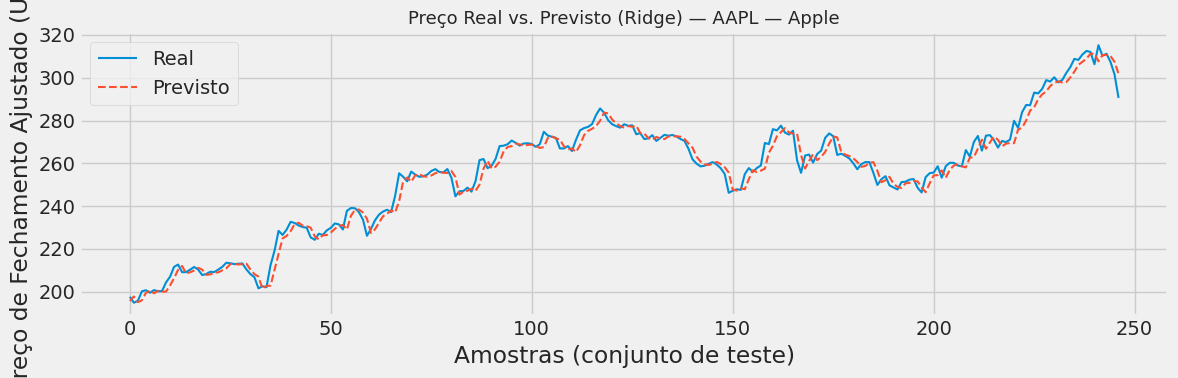

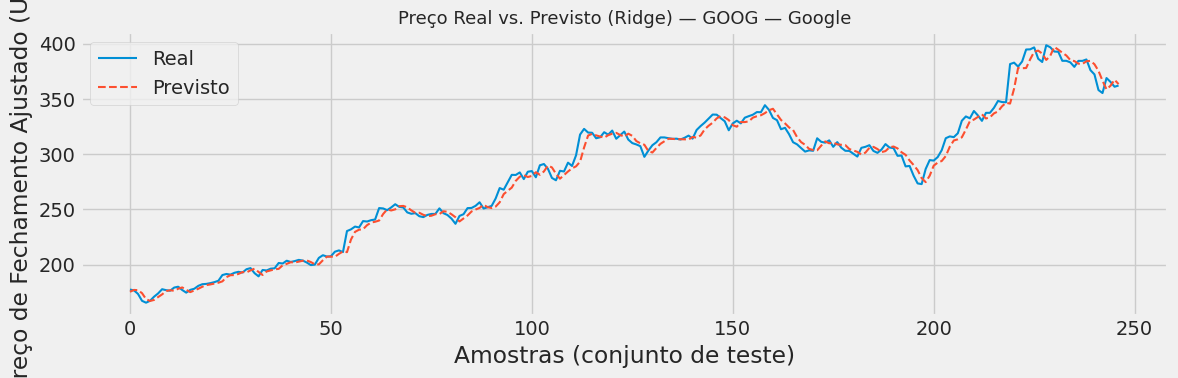

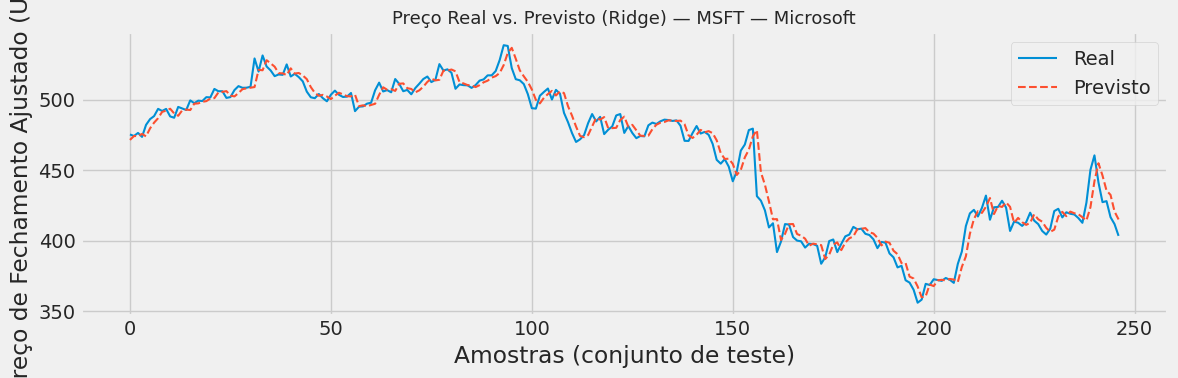

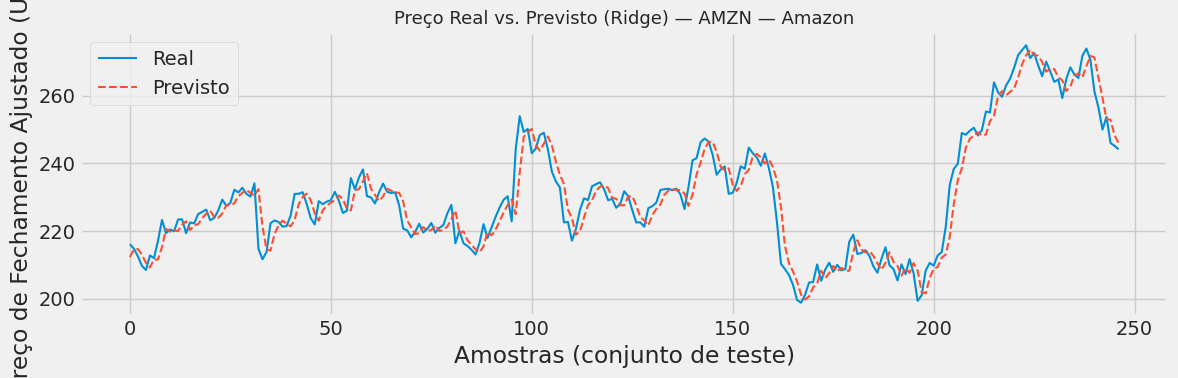

In [ ]:
for ticker in TICKERS:
    X_test = splits[ticker]["X_test"]
    y_test = splits[ticker]["y_test"]
    model  = trained_models[ticker][final_model_name]
    y_pred = model.predict(X_test)

    plot_predictions(y_test, y_pred,
                     title=f"Preço Real vs. Previsto ({final_model_name})",
                     ticker=f"{ticker} — {COMPANY_NAMES[ticker]}")


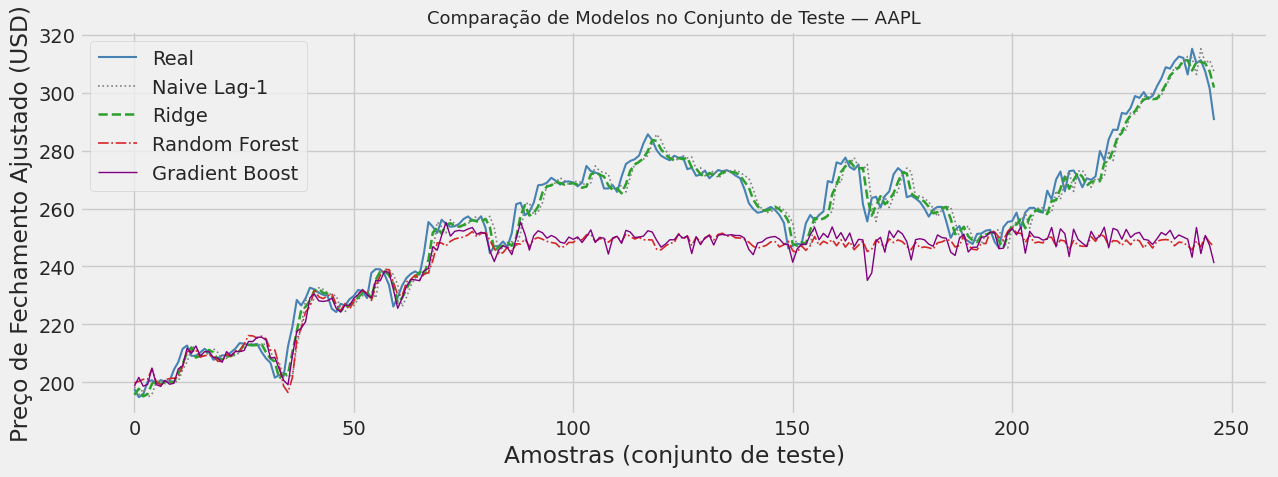

In [ ]:
# === Comparação visual de modelos — AAPL ===
# Sobrepõe Ridge, Naive Lag-1, Random Forest e Gradient Boosting no mesmo eixo,
# ilustrando visualmente o overfitting dos ensembles vs. a Ridge.

ticker_cmp  = "AAPL"
X_test_cmp  = splits[ticker_cmp]["X_test"]
y_test_cmp  = splits[ticker_cmp]["y_test"]

modelos_comparar = {
    "Naive Lag-1":    X_test_cmp["close_lag_1"].values,
    "Ridge":          trained_models[ticker_cmp]["Ridge"].predict(X_test_cmp),
    "Random Forest":  trained_models[ticker_cmp]["RandomForest"].predict(X_test_cmp),
    "Gradient Boost": trained_models[ticker_cmp]["GradientBoosting"].predict(X_test_cmp),
}

estilos = {
    "Naive Lag-1":   {"color": "gray",    "linestyle": ":",  "linewidth": 1.2},
    "Ridge":         {"color": "#2ca02c", "linestyle": "--", "linewidth": 1.8},
    "Random Forest": {"color": "#d62728", "linestyle": "-.", "linewidth": 1.2},
    "Gradient Boost":{"color": "purple",  "linestyle": "-",  "linewidth": 1.0},
}

fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(y_test_cmp.values, label="Real", color="steelblue", linewidth=1.5)

for nome, y_pred_cmp in modelos_comparar.items():
    ax.plot(y_pred_cmp, label=nome, **estilos[nome])

ax.set_title("Comparação de Modelos no Conjunto de Teste — AAPL", fontsize=13)
ax.set_xlabel("Amostras (conjunto de teste)")
ax.set_ylabel("Preço de Fechamento Ajustado (USD)")
ax.legend()
plt.tight_layout()
plt.show()

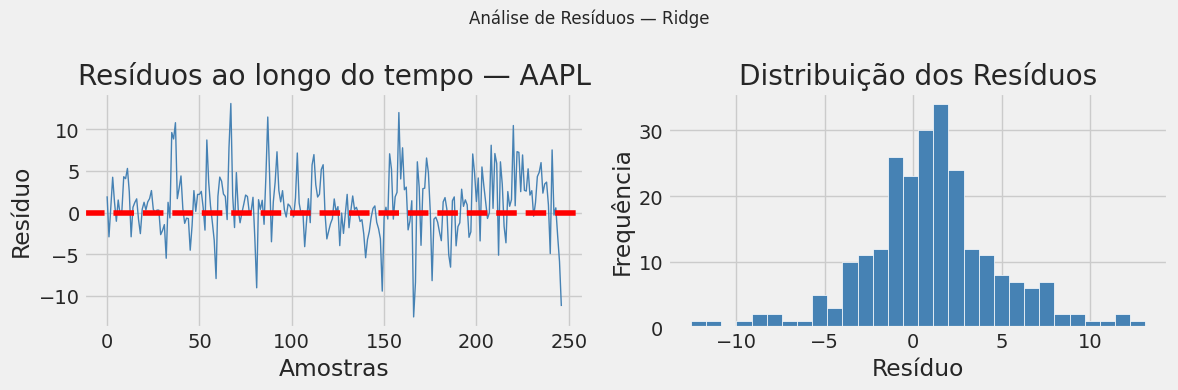

In [ ]:
ticker_plot = "AAPL"
X_test  = splits[ticker_plot]["X_test"]
y_test  = splits[ticker_plot]["y_test"]
y_pred  = trained_models[ticker_plot][final_model_name].predict(X_test)

plot_residuals(y_test, y_pred,
               title=f"Análise de Resíduos — {final_model_name}",
               ticker=ticker_plot)


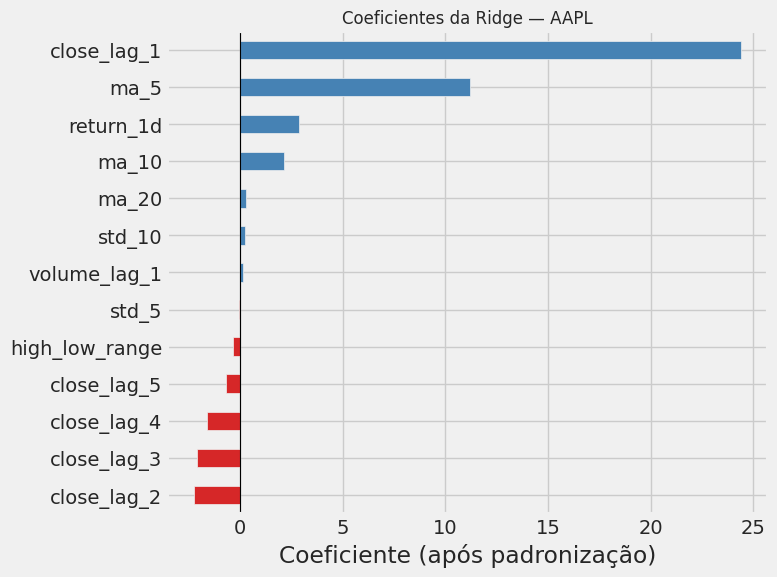

In [ ]:
ridge_model = trained_models["AAPL"]["Ridge"].named_steps["model"]
coefs = pd.Series(ridge_model.coef_, index=FEATURE_COLS).sort_values()

fig, ax = plt.subplots(figsize=(8, 6))
coefs.plot(kind="barh", color=["#d62728" if c < 0 else "steelblue" for c in coefs], ax=ax)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Coeficientes da Ridge — AAPL", fontsize=12)
ax.set_xlabel("Coeficiente (após padronização)")
plt.tight_layout()
plt.show()

## 10.6 Análise de Erros e Limitações

### Tipos de erro mais frequentes

A análise de resíduos da AAPL mostra que os erros oscilam de forma aparentemente
aleatória em torno de zero ao longo do tempo — sem tendência sistemática de
superestimação ou subestimação. No histograma, a distribuição é aproximadamente
simétrica, com a maioria dos erros concentrada entre −3 e +3 dólares. Isso indica
ausência de viés estrutural no modelo.

Os erros maiores (acima de ±10 USD) ocorrem em momentos pontuais de volatilidade
elevada — visíveis como picos isolados no gráfico temporal. São os casos onde o
modelo mais falha: variações abruptas causadas por eventos externos.

### Qualidade das previsões por ação

Nos gráficos de previsão vs. real com a Ridge a linha prevista acompanha a linha real de forma bastante próxima ao longo de todo
o período de teste — incluindo tendências de alta (GOOG, AAPL), quedas prolongadas
(MSFT na segunda metade do teste) e comportamento lateral volátil (AMZN).

O caso da MSFT é especialmente ilustrativo: o modelo acompanha tanto a fase de alta (~$470–$535) quanto a queda abrupta para ~$360, sem "travar" em uma faixa fixa. Isso confirma que a Ridge captura mudanças
de regime com muito mais eficácia neste conjunto de features.

### Sinais de overfitting ou underfitting

A Ridge não apresenta sinais de overfitting: R² acima de 0,97 no teste é
consistente com um modelo bem regularizado. A penalização L2 distribui os pesos
entre as features correlacionadas sem deixar o modelo sensível a flutuações
específicas do treino.

Tampouco há underfitting evidente — o modelo captura a maior parte da variância
explicável com as features disponíveis. O teto de desempenho está mais limitado
pela ausência de features externas do que pela capacidade do modelo em si.

### Coeficientes da Ridge

Os coeficientes do modelo revelam quais features mais influenciam a previsão.
`close_lag_1` domina com coeficiente ~24, seguido de `ma_5` (11) e `ma_10` (2)
— todos positivos, indicando que preços recentes e médias móveis de curto prazo
empurram a previsão para cima de forma proporcional.

Os lags mais distantes (`close_lag_2` a `close_lag_5`) têm coeficientes
negativos, o que faz sentido intuitivamente: dado que `close_lag_1` já captura
o nível recente do preço, os lags anteriores funcionam como um fator de
"correção" que suaviza a extrapolação linear.

Features como `volume_lag_1`, `std_5`, `std_10` e `high_low_range` têm
coeficientes próximos de zero — contribuição marginal para a previsão neste
modelo. Isso confirma que o problema é essencialmente autorregressivo de
primeira ordem e que a Ridge aprendeu a concentrar o peso nas informações
mais recentes, ignorando o ruído das features de menor sinal.

### Cenários onde o modelo não deveria ser usado

- **Períodos de crise ou quebra estrutural:** o modelo aprende padrões do período
  de treino. Em eventos sistêmicos sem precedente histórico recente, a
  generalização não é garantida.
- **Horizonte além de 1 dia:** o modelo foi construído exclusivamente para
  previsão do próximo pregão. Uso iterativo para múltiplos dias acumularia
  erros rapidamente.
- **Tomada de decisão autônoma de investimento:** as previsões não incorporam
  risco, custo de transação ou contexto macroeconômico — uso direto em
  estratégias de trading sem camadas adicionais de análise seria inadequado.

---
# 11. Comparação Final dos Modelos

O código abaixo compara todos os modelos treinados para **AAPL**, que usamos como caso de referência representativo, conforme a tabela.


In [ ]:
ticker_ref = "AAPL"
X_train_ref = splits[ticker_ref]["X_train"]
y_train_ref = splits[ticker_ref]["y_train"]
X_test_ref  = splits[ticker_ref]["X_test"]
y_test_ref  = splits[ticker_ref]["y_test"]

OBSERVACOES = {
    "Baseline (Média)": "Piso absoluto — ignora qualquer padrão temporal",
    "Naive Lag-1":      "Benchmark real — usa apenas o preço de ontem",
    "Ridge":            "Modelo final — melhor generalização, sem overfitting",
    "RandomForest":     "Overfitting — R² negativo no teste",
    "GradientBoosting": "Overfitting — R² negativo no teste",
    "RF Otimizado":     "Tuning não superou a versão padrão",
}

summary_rows = []

for model_name, model_obj in trained_models[ticker_ref].items():
    if model_name == "Naive Lag-1":
        t0 = time.time()
        y_pred_ref = X_test_ref["close_lag_1"].values
        elapsed = time.time() - t0
    else:
        t0 = time.time()
        model_obj.fit(X_train_ref, y_train_ref)
        elapsed = time.time() - t0
        y_pred_ref = model_obj.predict(X_test_ref)

    m = evaluate_regression(y_test_ref, y_pred_ref, model_name)
    m["Tempo (s)"] = round(elapsed, 3)
    m["Observação"] = OBSERVACOES.get(model_name, "—")
    summary_rows.append(m)

t0 = time.time()
rf_tuned.fit(X_train_ref, y_train_ref)
elapsed = time.time() - t0
y_pred_tuned_ref = rf_tuned.predict(X_test_ref)
m_tuned = evaluate_regression(y_test_ref, y_pred_tuned_ref, "RF Otimizado")
m_tuned["Tempo (s)"] = round(elapsed, 3)
m_tuned["Observação"] = OBSERVACOES["RF Otimizado"]
summary_rows.append(m_tuned)

summary_df = (
    pd.DataFrame(summary_rows)
    .set_index("Modelo")
)

num_cols = ["MAE", "RMSE", "R2", "Tempo (s)"]
summary_df[num_cols] = summary_df[num_cols].apply(pd.to_numeric, errors="coerce").round(4)

print(f"Comparação completa de modelos — {ticker_ref} ({COMPANY_NAMES[ticker_ref]}):")
display(summary_df)

best_model = summary_df["RMSE"].idxmin()
print(f"\n✅ Melhor RMSE: {best_model} ({summary_df.loc[best_model, 'RMSE']:.4f})")

Comparação completa de modelos — AAPL (Apple):


,MAE,RMSE,R2,MAPE(%),Tempo (s),Observação
Modelo,,,,,,
Baseline (Média),78.0188,82.6721,-8.1405,29.7155,0.001,Piso absoluto — ignora qualquer padrão temporal
Ridge,2.9012,3.9536,0.9791,1.1347,0.005,"Modelo final — melhor generalização, sem overf..."
RandomForest,16.0873,22.4776,0.3243,5.8400,1.068,Overfitting — R² negativo no teste
GradientBoosting,15.3081,21.7560,0.3670,5.5424,0.737,Overfitting — R² negativo no teste
RF Otimizado,17.0037,23.3479,0.2710,6.1847,0.797,Tuning não superou a versão padrão



✅ Melhor RMSE: Ridge (3.9536)


# 12. Boas Práticas e Rastreabilidade

## Configurações de reprodutibilidade

- **Seed global:** `SEED = 42` — aplicada ao NumPy, Random e todos os modelos via `random_state=SEED`
- **Dados:** carregados dinamicamente via `yfinance` com `auto_adjust=True`;
- **Dados:** carregados via `yfinance` com `auto_adjust=True`; data de corte fixada em 10/06/2026 para garantir reprodutibilidade total
- **Ambiente:** CPU padrão do Google Colab; tempo total de execução estimado em < 5 minutos

---

## Registro de decisões

| Decisão | Justificativa | Impacto esperado |
|---|---|---|
| Divisão temporal 80/20 sem embaralhamento | Séries temporais não podem ter dados futuros no treino | Avaliação realista do poder preditivo |
| `StandardScaler` dentro do Pipeline | Evitar que estatísticas do teste contaminem o treino | Elimina leakage na normalização |
| Target com `shift(-1)` | Garantir que o modelo sempre prevê algo ainda não ocorrido | Elimina leakage no target |
| `rolling()` para médias móveis e desvio padrão | Função causal — usa apenas dados passados | Features seguras sem leakage velado |
| `TimeSeriesSplit` na otimização | Preservar ordem temporal dentro da validação cruzada | Hiperparâmetros válidos para dados futuros |
| Lags 1–5 + médias móveis como features | Indicadores técnicos clássicos, amplamente validados em literatura | Features informativas e interpretáveis |
| Remover colunas `Ticker` e `Company` das features | Variáveis de identificação, sem poder preditivo | Evitar ruído no modelo |
| Ridge escolhida como modelo final | Melhor RMSE e R² no teste; Random Forest e Gradient Boosting apresentaram R² negativo (overfitting) | Generalização superior e modelo mais parcimonioso |
| Gradient Boosting e Random Forest descartados como modelo final | Overfitting confirmado — R² negativo no teste apesar de alta capacidade | Modelos complexos não se justificam neste espaço de features lineares |
| Otimização limitada a 15 iterações | Manter execução em ~60s no Colab | Busca suficiente para explorar o espaço sem custo excessivo |
| `dropna()` após engenharia de features | Linhas iniciais sem histórico suficiente para lags e rolling | Elimina NaN sem distorcer a série |


# 13. Conclusão

## O que foi feito

O objetivo deste MVP era construir um pipeline completo de Machine Learning para prever o preço de fechamento do dia seguinte de quatro ações de tecnologia — Apple, Google, Microsoft e Amazon — usando apenas dados históricos de preço e volume.

O melhor modelo encontrado foi a **Ridge Regression**, com erro médio entre 3 e 8 dólares por ação e R² acima de 0,97 em todos os casos.

## O resultado mais interessante

O que mais chamou atenção não foi o bom desempenho da Ridge, mas o fato de modelos muito mais complexos — Random Forest e Gradient Boosting — terem ficado abaixo até do baseline mais simples. Isso revela algo importante sobre o problema: a relação entre os preços passados e o preço do dia seguinte é essencialmente linear. Os coeficientes da Ridge confirmam isso — o preço de ontem (`close_lag_1`) domina completamente a previsão, com as médias móveis contribuindo de forma secundária.

Em outras palavras: o melhor preditor do preço de amanhã é o preço de hoje, com um pequeno ajuste pela tendência recente. Modelos que tentaram ir além disso acabaram memorizando o treino.

## O que aprendi

- Modelo mais complexo não significa modelo melhor. A escolha depende da natureza do problema.
- Identificar overfitting cedo evitou escolher o modelo errado como solução final.
- Aprendia a explorar novos modelos e fugir um pouco dos modelos padrões que geralmente utilizada durante a graduação e no trabalho, série temporal foi um desafio interessante que me tirou da zona de conforto

## Limitações

O modelo não enxerga nada além do histórico de preços e volume. Resultados de balanços, decisões do Fed, notícias e eventos geopolíticos afetam preços de forma abrupta e estão completamente fora do alcance do modelo. Assim, é válido apenas para previsão de 1 dia.
## Próximos passos

- Adicionar features externas: índice de volatilidade, taxa de juros, S&P 500.
- Testar modelos específicos para séries temporais: ARIMA, Prophet, LSTM.
- Reformular o problema prevendo retornos em vez de preços absolutos — série mais estacionária e matematicamente mais adequada.
- Implementar um backtesting simples para avaliar se as previsões gerariam retorno real em uma estratégia de trading.